# What Drives Airbnb Prices in Vancouver? A Multiple Regression on Log Price

## Introduction

Airbnb hosts set nightly prices based on what they offer (space, room type, bathrooms), how they're perceived (ratings, superhost status), and where they are. This project asks:

> **Holding other listing characteristics fixed, how much more do entire homes cost than private rooms, and how much of a premium do superhosts charge?**

We answer it with a multiple linear regression on **log nightly price**, so each coefficient reads as an approximate *percentage* difference in price. Variables are chosen with AIC-based stepwise selection and the model is checked with residual diagnostics and variance inflation factors (VIFs). Predictive accuracy is measured on a held-out test set.

**Data.** [Inside Airbnb](http://insideairbnb.com/get-the-data/) scrape of City of Vancouver listings from December 2023 (`data/vancouver_listings_2023-12.csv`, a column subset of the public `listings.csv`). Inside Airbnb licenses the data under CC BY 4.0.

*This notebook replaces our original DSCI 100 project (Paris listings, K-NN), which is kept in `archive/`.*

In [1]:
# install.packages(c("tidyverse", "tidymodels", "car", "broom"))  # if needed
suppressPackageStartupMessages({
    library(tidyverse)
    library(rsample)   # part of tidymodels; used for the stratified split
    library(broom)
    library(car)       # vif()
})
options(repr.matrix.max.rows = 30, repr.plot.width = 12, repr.plot.height = 7)
theme_set(theme_minimal(base_size = 16))
dir.create("figures", showWarnings = FALSE)

## Data cleaning

Starting from one snapshot (so each listing appears once), we:

- keep **entire homes/apartments** and **private rooms** (shared and hotel rooms are too rare to model),
- keep **short-term** listings (minimum stay under 30 nights); monthly rentals are priced on a different basis,
- require **at least 3 reviews**, which removes inactive or placeholder listings and makes the rating meaningful,
- keep nightly prices between **\$30 and \$1,000**, removing obvious placeholder prices (e.g. \$20,000),
- parse the number of bathrooms and whether they're shared from free text,
- compute each listing's straight-line distance to downtown (Waterfront Station).

In [2]:
raw <- read_csv("data/vancouver_listings_2023-12.csv",
                col_types = cols(id = col_character(), .default = col_guess()))

# great-circle distance (km) to Waterfront Station
dist_to_downtown <- function(lat, lon, lat0 = 49.2856, lon0 = -123.1115) {
    rad <- pi / 180
    a <- sin((lat - lat0) * rad / 2)^2 +
         cos(lat * rad) * cos(lat0 * rad) * sin((lon - lon0) * rad / 2)^2
    2 * 6371 * asin(sqrt(a))
}

airbnb <- raw |>
    mutate(price        = parse_number(price),
           bathrooms_tx = str_to_lower(bathrooms_text),
           baths        = parse_number(str_replace(bathrooms_tx, "half-bath", "0.5")),
           shared_bath  = str_detect(bathrooms_tx, "shared"),
           dist_km      = dist_to_downtown(latitude, longitude)) |>
    filter(room_type %in% c("Entire home/apt", "Private room"),
           minimum_nights < 30,
           number_of_reviews >= 3,
           between(price, 30, 1000)) |>
    transmute(price,
              room_type     = factor(room_type, levels = c("Private room", "Entire home/apt")),
              superhost     = host_is_superhost,
              accommodates, beds, baths, shared_bath,
              rating        = review_scores_rating,
              n_reviews     = number_of_reviews,
              instant_book  = instant_bookable,
              dist_km,
              neighbourhood = fct_relevel(factor(neighbourhood_cleansed), "Downtown"),
              availability  = availability_365,
              host_listings = calculated_host_listings_count) |>
    drop_na()

cat("Listings in snapshot:", nrow(raw), "\nListings after cleaning:", nrow(airbnb), "\n")
airbnb |> count(room_type, superhost)

Listings in snapshot: 6691 
Listings after cleaning: 2955 


room_type,superhost,n
<fct>,<lgl>,<int>
Private room,FALSE,256
Private room,TRUE,234
Entire home/apt,FALSE,1006
Entire home/apt,TRUE,1459


## Train/test split

We hold out 25% of listings as a test set (stratified on price, seed 8888 as in our original project). All exploration, fitting and model selection below uses only the training set.

In [3]:
set.seed(8888)
airbnb_split <- initial_split(airbnb, prop = 0.75, strata = price)
train <- training(airbnb_split)
test  <- testing(airbnb_split)
cat("Training:", nrow(train), " Test:", nrow(test), "\n")

train |>
    summarise(across(c(price, accommodates, beds, baths, rating, n_reviews, dist_km, availability, host_listings),
                     list(mean = mean, median = median, sd = sd))) |>
    pivot_longer(everything(), names_to = c("variable", ".value"), names_pattern = "(.*)_(mean|median|sd)$") |>
    mutate(across(where(is.numeric), \(x) round(x, 2)))

Training: 2216  Test: 739 


variable,mean,median,sd
<chr>,<dbl>,<dbl>,<dbl>
price,185.59,148.00,131.14
accommodates,3.91,4.00,2.11
beds,2.10,2.00,1.19
baths,1.34,1.00,0.65
rating,4.81,4.86,0.22
n_reviews,72.11,41.00,90.83
dist_km,3.81,3.73,2.53
availability,121.18,82.50,117.97
host_listings,4.14,1.00,15.02


## Exploratory analysis

Nightly prices are strongly right-skewed. On the log scale the distribution is roughly symmetric, which is the main reason we model `log(price)`: it stabilises the variance and turns multiplicative effects (e.g. "entire homes cost X% more") into additive coefficients.

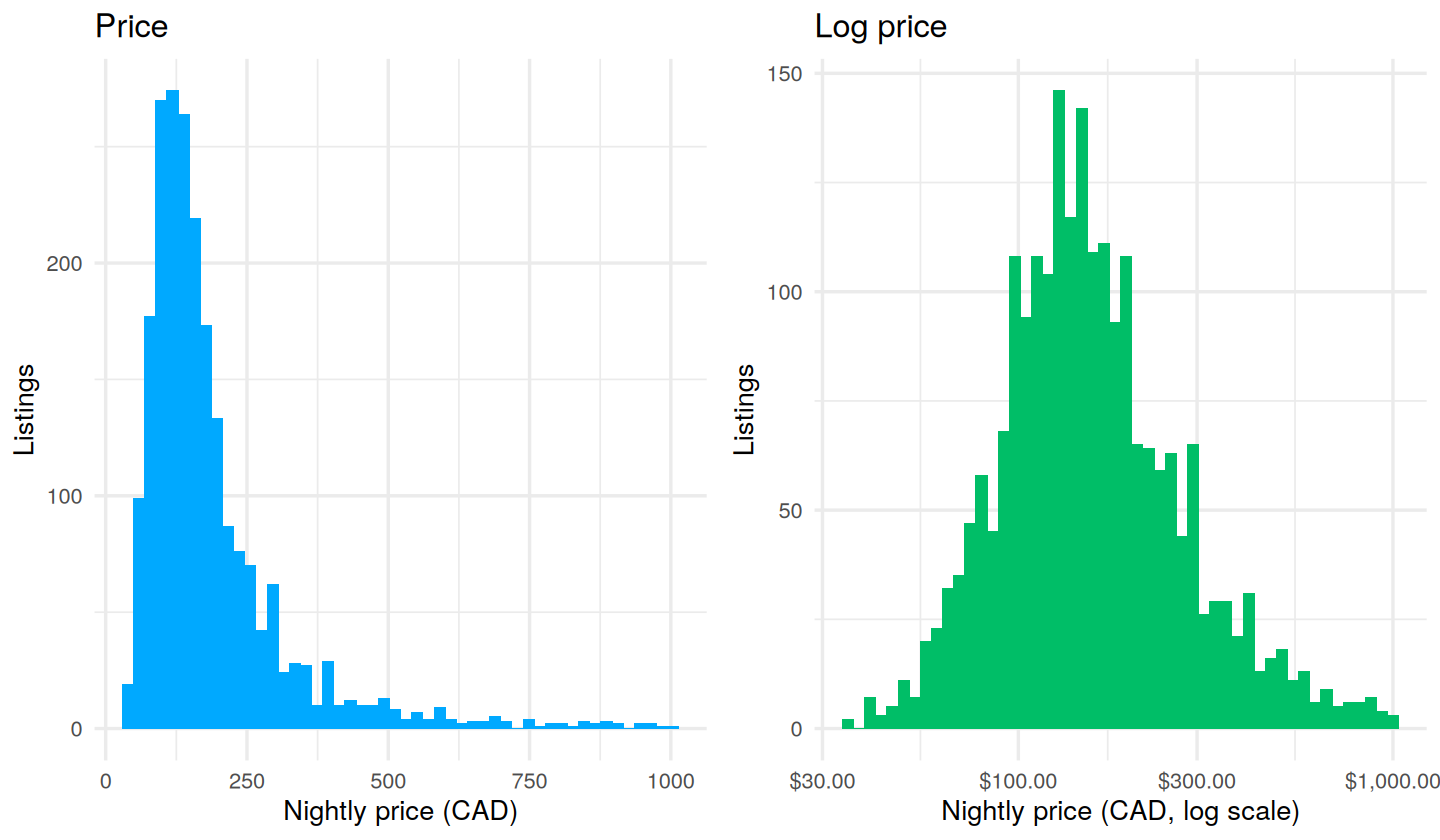

In [4]:
p_raw <- ggplot(train, aes(price)) + geom_histogram(bins = 50, fill = "#00A9FF") +
    labs(x = "Nightly price (CAD)", y = "Listings", title = "Price")
p_log <- ggplot(train, aes(price)) + geom_histogram(bins = 50, fill = "#00BE67") +
    scale_x_log10(labels = scales::dollar) +
    labs(x = "Nightly price (CAD, log scale)", y = "Listings", title = "Log price")
p_both <- gridExtra::arrangeGrob(p_raw, p_log, ncol = 2)
grid::grid.draw(p_both)
ggsave("figures/price_distribution.png", p_both, width = 12, height = 5)

room_type,n,median_price,mean_accommodates
<fct>,<int>,<dbl>,<dbl>
Private room,376,96,2.212766
Entire home/apt,1840,159,4.255978


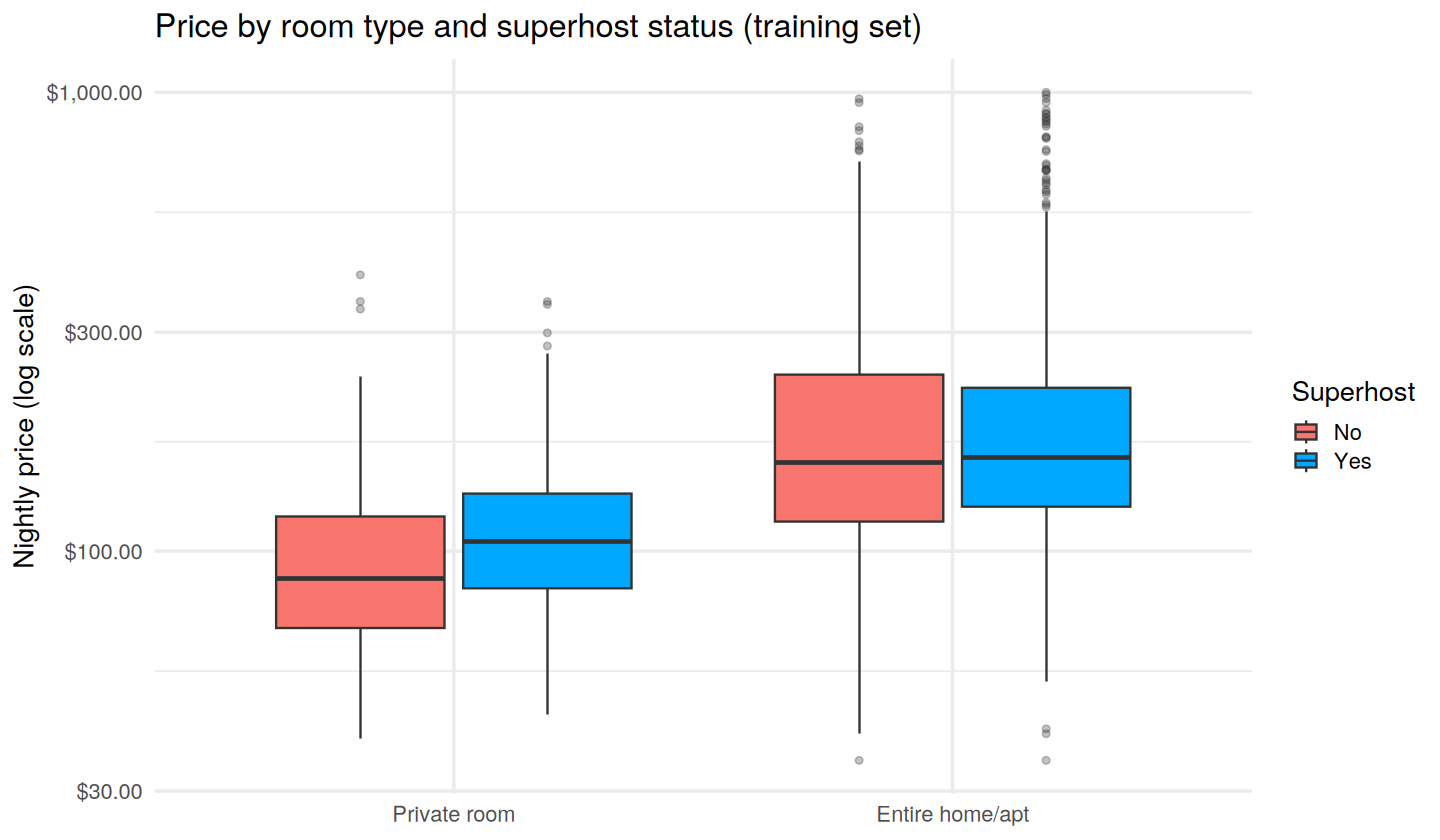

In [5]:
ggplot(train, aes(room_type, price, fill = superhost)) +
    geom_boxplot(outlier.alpha = 0.3) +
    scale_y_log10(labels = scales::dollar) +
    scale_fill_manual(values = c("#F8766D", "#00A9FF"), labels = c("No", "Yes")) +
    labs(x = NULL, y = "Nightly price (log scale)", fill = "Superhost",
         title = "Price by room type and superhost status (training set)")

train |> group_by(room_type) |> summarise(n = n(), median_price = median(price), mean_accommodates = mean(accommodates))

The raw gap between entire homes and private rooms is large, but entire homes also sleep more people and have more (and private) bathrooms. Regression lets us separate the room-type effect from those size differences.

## Model selection with AIC

We start from a full model containing all 13 candidate predictors. Count-like and distance variables that are right-skewed enter on the log scale. We then run bidirectional stepwise selection with `step()`, which adds or drops terms whenever that lowers AIC.

In [6]:
full_model <- lm(log(price) ~ room_type + superhost + accommodates + beds + baths + shared_bath +
                     rating + log1p(n_reviews) + instant_book + log(dist_km) + neighbourhood +
                     availability + log(host_listings),
                 data = train)

null_model <- lm(log(price) ~ 1, data = train)

final_model <- step(full_model, direction = "both",
                    scope = list(lower = ~ 1, upper = formula(full_model)), trace = 0)
formula(final_model)

log(price) ~ room_type + superhost + accommodates + beds + baths + 
    shared_bath + rating + log1p(n_reviews) + instant_book + 
    log(dist_km) + neighbourhood + availability + log(host_listings)

In [7]:
# AIC change from dropping each term from the selected model (positive = term is worth keeping)
# In our run, stepwise selection keeps all 13 terms: dropping any of them raises AIC.
drop1(final_model) |>
    as_tibble(rownames = "term") |>
    mutate(delta_AIC = AIC - AIC[term == "<none>"]) |>
    arrange(desc(delta_AIC)) |>
    select(term, Df, delta_AIC) |>
    mutate(delta_AIC = round(delta_AIC, 1))

tibble(model = c("Intercept only", "Full", "AIC-selected"),
       AIC   = c(AIC(null_model), AIC(full_model), AIC(final_model)),
       adj_R2 = c(0, summary(full_model)$adj.r.squared, summary(final_model)$adj.r.squared)) |>
    mutate(across(where(is.numeric), \(x) round(x, 3)))

term,Df,delta_AIC
<chr>,<dbl>,<dbl>
baths,1,172.8
neighbourhood,22,146.7
log(host_listings),1,89.2
log1p(n_reviews),1,69.0
availability,1,54.7
accommodates,1,42.7
shared_bath,1,26.0
rating,1,13.0
room_type,1,11.5


model,AIC,adj_R2
<chr>,<dbl>,<dbl>
Intercept only,3712.094,0.000
Full,2045.449,0.536
AIC-selected,2045.449,0.536


Stepwise selection retained every candidate term, so the selected model is the full model. The `drop1` table shows why: removing any single term would raise AIC, with bathrooms, neighbourhood and host portfolio size contributing the most. Compared with an intercept-only model, AIC falls by over 1,600.

## Multicollinearity (VIF)

Because `neighbourhood` is a factor with many levels, `car::vif()` reports generalised VIFs. The comparable column is $\text{GVIF}^{1/(2\,\text{Df})}$; squaring it puts it back on the usual VIF scale, where values above ~5 (squared) signal problematic collinearity.

In [8]:
vif_table <- vif(final_model) |>
    as_tibble(rownames = "term") |>
    mutate(adj_VIF = `GVIF^(1/(2*Df))`^2) |>
    arrange(desc(adj_VIF)) |>
    mutate(across(where(is.numeric), \(x) round(x, 2)))
vif_table

term,GVIF,Df,GVIF^(1/(2*Df)),adj_VIF
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
log(dist_km),10.67,1,3.27,10.67
accommodates,5.76,1,2.40,5.76
beds,4.83,1,2.20,4.83
baths,2.06,1,1.44,2.06
room_type,2.03,1,1.42,2.03
shared_bath,1.76,1,1.33,1.76
superhost,1.31,1,1.14,1.31
rating,1.25,1,1.12,1.25
log1p(n_reviews),1.19,1,1.09,1.19


Most adjusted VIFs are between 1 and 2, including room type and superhost status. Two groups stand out, and both are expected: `accommodates` and `beds` overlap because bigger places sleep more people and have more beds (moderate, about 5), and `log(dist_km)` is highly collinear with `neighbourhood` (about 11) because each neighbourhood sits at a fairly fixed distance from downtown. Collinearity inflates the standard errors of the terms involved but doesn't bias the other coefficients. As a check, we refit without `log(dist_km)` and confirm that the two effects we interpret barely move.

In [9]:
no_dist <- update(final_model, . ~ . - log(dist_km))
bind_rows(`AIC-selected` = tidy(final_model), `without log(dist_km)` = tidy(no_dist), .id = "model") |>
    filter(term %in% c("room_typeEntire home/apt", "superhostTRUE")) |>
    mutate(pct_effect = round(100 * (exp(estimate) - 1), 1), std.error = round(std.error, 4)) |>
    select(model, term, pct_effect, std.error)
cat("Largest adjusted VIF without log(dist_km):", round(max(vif(no_dist)[, "GVIF^(1/(2*Df))"]^2), 2), "\n")

model,term,pct_effect,std.error
<chr>,<chr>,<dbl>,<dbl>
AIC-selected,room_typeEntire home/apt,11.9,0.0307
AIC-selected,superhostTRUE,6.6,0.0187
without log(dist_km),room_typeEntire home/apt,11.7,0.0308
without log(dist_km),superhostTRUE,6.7,0.0187


Largest adjusted VIF without log(dist_km): 5.76 


## Residual diagnostics

Max Cook's distance: 0.018 


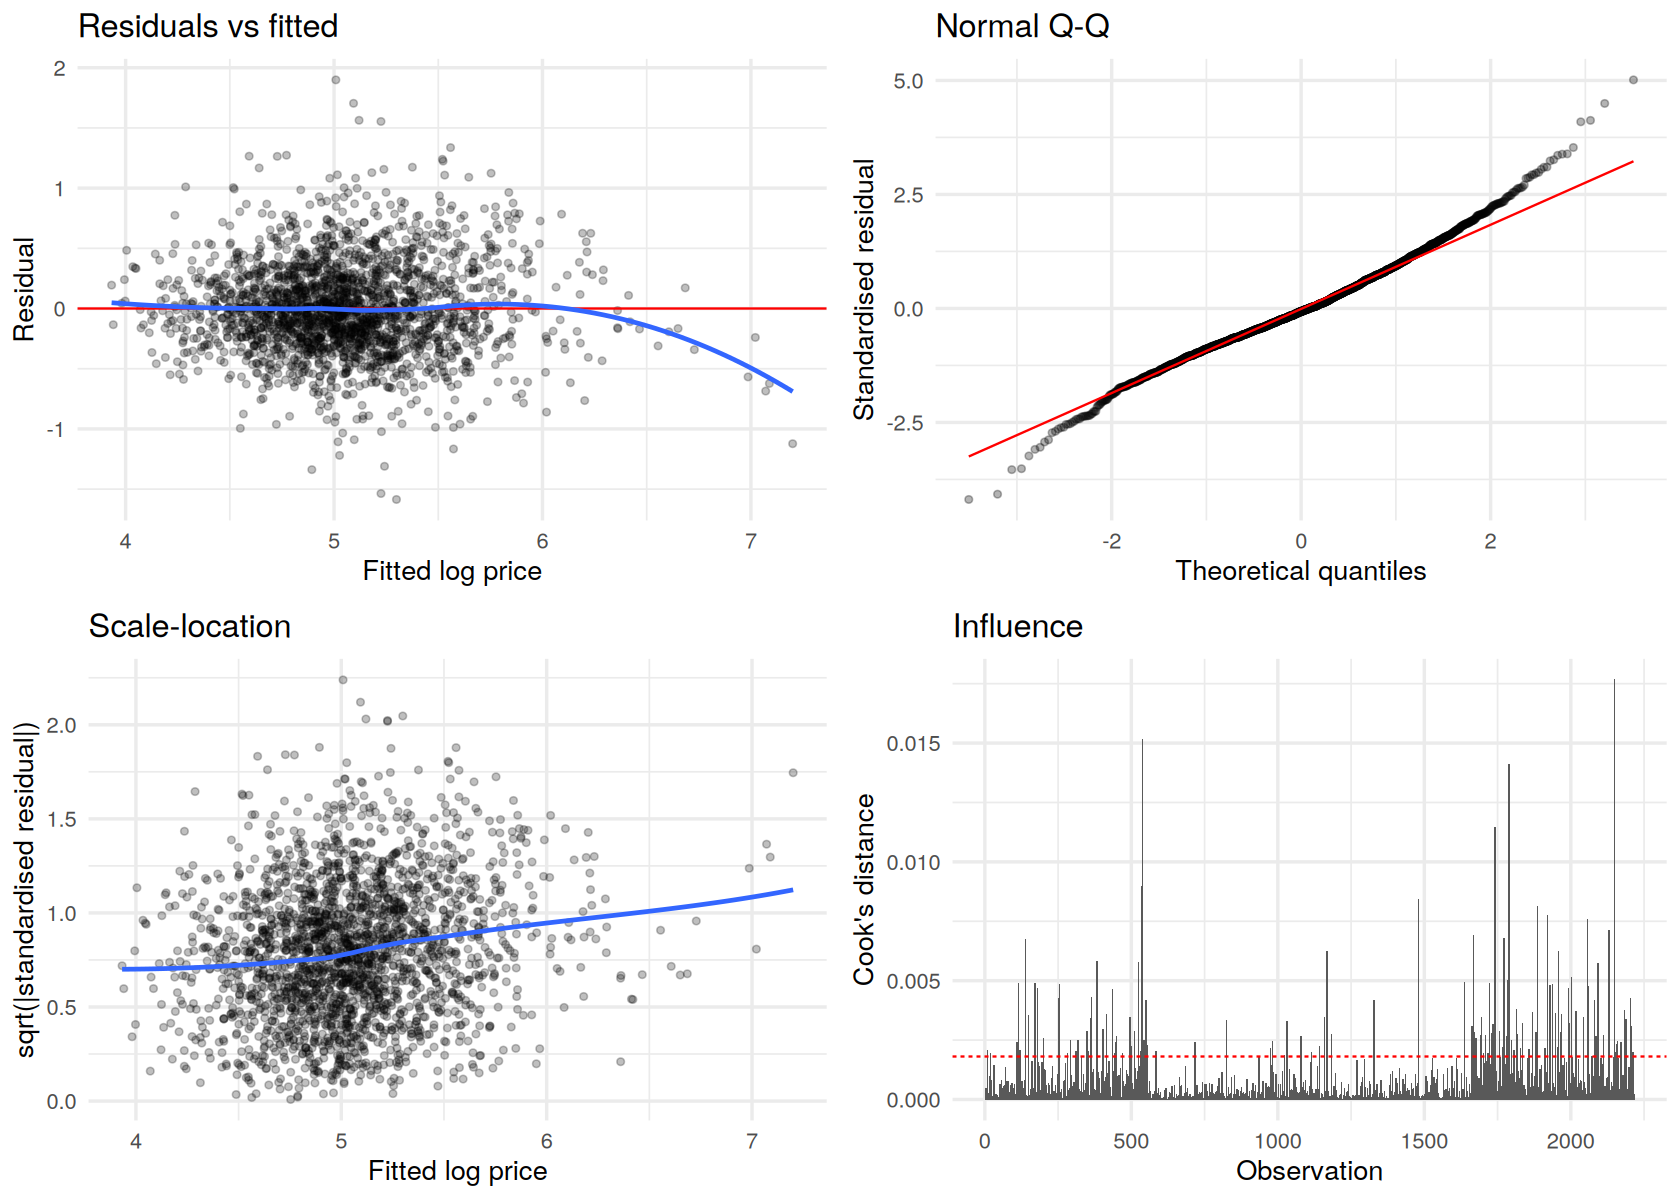

In [10]:
diag_df <- augment(final_model)

p1 <- ggplot(diag_df, aes(.fitted, .resid)) + geom_point(alpha = 0.25) +
    geom_hline(yintercept = 0, colour = "red") + geom_smooth(se = FALSE, method = "loess", formula = y ~ x) +
    labs(x = "Fitted log price", y = "Residual", title = "Residuals vs fitted")
p2 <- ggplot(diag_df, aes(sample = .std.resid)) + stat_qq(alpha = 0.3) + stat_qq_line(colour = "red") +
    labs(x = "Theoretical quantiles", y = "Standardised residual", title = "Normal Q-Q")
p3 <- ggplot(diag_df, aes(.fitted, sqrt(abs(.std.resid)))) + geom_point(alpha = 0.25) +
    geom_smooth(se = FALSE, method = "loess", formula = y ~ x) +
    labs(x = "Fitted log price", y = "sqrt(|standardised residual|)", title = "Scale-location")
p4 <- ggplot(diag_df, aes(seq_along(.cooksd), .cooksd)) + geom_col() +
    geom_hline(yintercept = 4 / nrow(diag_df), colour = "red", linetype = "dashed") +
    labs(x = "Observation", y = "Cook's distance", title = "Influence")

options(repr.plot.width = 14, repr.plot.height = 10)
diag_grid <- gridExtra::arrangeGrob(p1, p2, p3, p4, ncol = 2)
grid::grid.draw(diag_grid)
ggsave("figures/residual_diagnostics.png", diag_grid, width = 14, height = 10)

cat("Max Cook's distance:", round(max(diag_df$.cooksd), 3), "\n")

**Reading the diagnostics.** The residuals-vs-fitted smoother stays near zero across almost the whole range, so the log-linear form fits the bulk of listings; it bends downward only for the handful of listings with the highest predicted prices, which the model overestimates. The scale-location curve rises gently, so some heteroscedasticity remains even after the log transform (errors are a bit larger for pricier listings). The Q-Q plot shows a heavier right tail than a normal distribution: some listings are priced well above what their features suggest. No listing has a Cook's distance anywhere near 1, so no single point drives the fit.

Because of the mild heteroscedasticity, we recheck the two headline effects with heteroscedasticity-robust (HC3) standard errors.

In [11]:
robust_se <- sqrt(diag(hccm(final_model, type = "hc3")))
tidy(final_model) |>
    mutate(robust_se = robust_se[term]) |>
    filter(term %in% c("room_typeEntire home/apt", "superhostTRUE")) |>
    transmute(term,
              pct_effect  = round(100 * (exp(estimate) - 1), 1),
              classic_CI  = sprintf("%.1f%% to %.1f%%", 100 * (exp(estimate - 1.96 * std.error) - 1), 100 * (exp(estimate + 1.96 * std.error) - 1)),
              robust_CI   = sprintf("%.1f%% to %.1f%%", 100 * (exp(estimate - 1.96 * robust_se) - 1), 100 * (exp(estimate + 1.96 * robust_se) - 1)))

term,pct_effect,classic_CI,robust_CI
<chr>,<dbl>,<chr>,<chr>
room_typeEntire home/apt,11.9,5.3% to 18.8%,6.0% to 18.1%
superhostTRUE,6.6,2.7% to 10.5%,2.6% to 10.7%


Both intervals stay above zero with robust standard errors, so the conclusions don't depend on the constant-variance assumption.

## Coefficients: adjusted price differences

Because the outcome is log price, a coefficient $\beta$ on an indicator corresponds to a $100(e^{\beta}-1)\%$ difference in price, holding the other predictors fixed.

In [12]:
coef_table <- tidy(final_model, conf.int = TRUE) |>
    filter(!str_detect(term, "neighbourhood")) |>
    mutate(pct_effect = 100 * (exp(estimate) - 1),
           pct_low    = 100 * (exp(conf.low) - 1),
           pct_high   = 100 * (exp(conf.high) - 1)) |>
    select(term, estimate, std.error, p.value, pct_effect, pct_low, pct_high) |>
    mutate(across(c(estimate, std.error, pct_effect, pct_low, pct_high), \(x) round(x, 3)),
           p.value = signif(p.value, 3))
coef_table

term,estimate,std.error,p.value,pct_effect,pct_low,pct_high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.891,0.201,2.78e-77,4793.536,3200.612,7155.227
room_typeEntire home/apt,0.112,0.031,2.64e-04,11.875,5.337,18.818
superhostTRUE,0.064,0.019,6.68e-04,6.567,2.737,10.541
accommodates,0.061,0.009,3.31e-11,6.333,4.430,8.272
beds,0.047,0.015,1.76e-03,4.785,1.762,7.898
baths,0.238,0.018,2.76e-39,26.912,22.555,31.424
shared_bathTRUE,-0.214,0.041,1.49e-07,-19.234,-25.405,-12.553
rating,0.159,0.041,1.23e-04,17.279,8.127,27.206
log1p(n_reviews),-0.065,0.008,6.44e-17,-6.261,-7.661,-4.840


In [13]:
effect_of <- function(term_name) filter(coef_table, term == term_name)
room  <- effect_of("room_typeEntire home/apt")
super <- effect_of("superhostTRUE")

raw_gap <- train |> group_by(room_type) |> summarise(m = mean(log(price))) |> pull(m) |> diff()

cat(sprintf("Entire home vs private room: unadjusted %.0f%%, adjusted %.1f%% (95%% CI %.1f%% to %.1f%%)\n",
            100 * (exp(raw_gap) - 1), room$pct_effect, room$pct_low, room$pct_high))
cat(sprintf("Superhost vs not:            adjusted %.1f%% (95%% CI %.1f%% to %.1f%%)\n",
            super$pct_effect, super$pct_low, super$pct_high))

Entire home vs private room: unadjusted 74%, adjusted 11.9% (95% CI 5.3% to 18.8%)


Superhost vs not:            adjusted 6.6% (95% CI 2.7% to 10.5%)


## Test-set performance

Predictions are made on the log scale and converted back to dollars. Simply exponentiating a log-scale prediction estimates the *median* price, which is biased low for the mean, so we multiply by Duan's smearing factor $\frac{1}{n}\sum e^{\hat\varepsilon_i}$ from the training residuals. We compare against a baseline that predicts the training median for every listing.

In [14]:
smear <- mean(exp(residuals(final_model)))

test_results <- test |>
    mutate(pred_log = predict(final_model, newdata = test),
           pred     = exp(pred_log) * smear,
           baseline = median(train$price))

rmse <- function(y, yhat) sqrt(mean((y - yhat)^2))
mae  <- function(y, yhat) mean(abs(y - yhat))

metrics <- test_results |>
    summarise(n_test          = n(),
              median_price    = median(price),
              RMSE            = rmse(price, pred),
              MAE             = mae(price, pred),
              median_abs_err  = median(abs(price - pred)),
              baseline_RMSE   = rmse(price, baseline),
              R2_log_scale    = cor(log(price), pred_log)^2,
              R2_dollar_scale = 1 - sum((price - pred)^2) / sum((price - mean(price))^2)) |>
    mutate(across(where(is.double), \(x) round(x, 3)))
metrics |> pivot_longer(everything(), names_to = "metric", values_to = "value")

metric,value
<chr>,<dbl>
n_test,739.000
median_price,147.000
RMSE,99.524
MAE,57.395
median_abs_err,34.774
baseline_RMSE,138.955
R2_log_scale,0.606
R2_dollar_scale,0.440


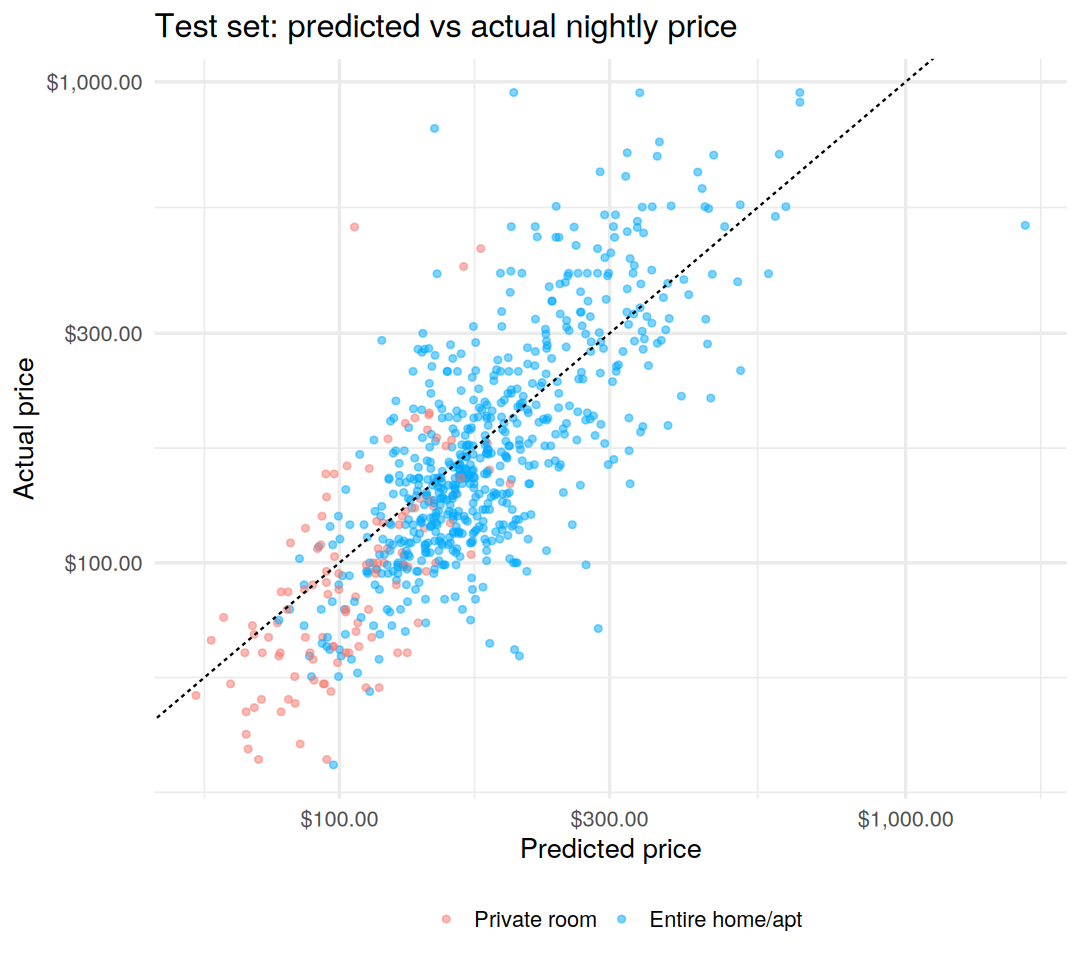

In [15]:
options(repr.plot.width = 9, repr.plot.height = 8)
pred_plot <- ggplot(test_results, aes(pred, price, colour = room_type)) +
    geom_point(alpha = 0.5) +
    geom_abline(linetype = "dashed") +
    scale_x_log10(labels = scales::dollar) + scale_y_log10(labels = scales::dollar) +
    scale_colour_manual(values = c("#F8766D", "#00A9FF")) +
    labs(x = "Predicted price", y = "Actual price", colour = NULL,
         title = "Test set: predicted vs actual nightly price") +
    theme(legend.position = "bottom")
pred_plot
ggsave("figures/test_predictions.png", pred_plot, width = 9, height = 8)

## Discussion

**Room type.** The unadjusted gap between entire homes and private rooms is large, but most of it is explained by size: entire homes sleep more guests and have more, and private, bathrooms. After adjusting for those features, entire homes still command a statistically significant premium, but a much smaller one (see the output above). In other words, guests mostly pay for space and privacy, and "entire home" on its own adds a modest amount on top.

**Superhosts.** Superhost listings are priced a few percent higher than comparable non-superhost listings. This is an association, not a causal effect: hosts who earn the badge may differ in ways we don't measure (photos, décor, responsiveness).

**Other predictors.** Bathrooms are the strongest single driver; shared bathrooms carry a clear discount. Distance from downtown and neighbourhood both matter. Listings with many reviews, and hosts with many listings, are priced lower, consistent with high-volume, competitively priced units.

**Prediction.** The model explains a little over half of the variation in log price on unseen data and clearly beats the median-price baseline. Errors in dollars are dominated by a small number of expensive listings, which is why RMSE is well above the median absolute error. Features we don't observe (photos, views, amenities, dates) likely account for much of the rest.

**Limitations.** The data is a single December 2023 snapshot of the City of Vancouver only (not the wider Lower Mainland), and listed prices are not necessarily prices paid. Filtering to active, short-term listings means results apply to that segment. Stepwise AIC selection is convenient but can overstate the certainty of the selected terms, so p-values should be read as descriptive.

## References

- Inside Airbnb. *Vancouver, British Columbia, Canada — listings.csv* (scraped 13–14 December 2023). http://insideairbnb.com/get-the-data/ (CC BY 4.0). Copy obtained via the UBC-MDS-2023-24/DSCI-532_2024_18_VancouverAirbnbPrices repository.
- Duan, N. (1983). Smearing estimate: a nonparametric retransformation method. *Journal of the American Statistical Association*, 78(383), 605–610.
- Fox, J., & Monette, G. (1992). Generalized collinearity diagnostics. *Journal of the American Statistical Association*, 87(417), 178–183.
- Timbers, T., Campbell, T., & Lee, M. (2022). *Data Science: A First Introduction*. CRC Press.